# Market Basket Analysis with Python - eBay

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("eBay.csv")

## Task 1 Data Cleaning and Preparation

### 1.1 Remove duplicate or inconsistent survey responses

In [3]:
df = df.drop_duplicates()

In [4]:
cols = ['Service_Appreciation', 'Improvement_Areas']
df[cols] = df[cols].replace('.', "NA")

In [5]:
df['Purchase_Categories'] = df['Purchase_Categories'].str.split(';').str[0]

#### This step removes repeated survey entries so that each customer response is counted only once, ensuring accurate and unbiased analysis.

### 1.2 Standardize categorical/numerical entries (e.g., frequency levels, gender, recommendation responses).

In [6]:
purchase_map = {
    'Multiple times a week': 'High',
    'Once a week': 'High',
    'Few times a month': 'Medium',
    'Once a month': 'Medium',
    'Less than once a month': 'Low'
}

df['Purchase_Frequency'] = df['Purchase_Frequency'].map(purchase_map)

In [7]:
df['Purchase_Frequency'].head()

0      High
1      High
2    Medium
3    Medium
4      High
Name: Purchase_Frequency, dtype: object

In [8]:
browsing_map = {
    'Multiple times a day': 'High',
    'Few times a week': 'High',
    'Few times a month': 'Medium',
    'Rarely': 'Low'
}

df['Browsing_Frequency'] = df['Browsing_Frequency'].map(browsing_map)

In [9]:
df['Browsing_Frequency'].head()

0       Low
1    Medium
2      High
3       Low
4       Low
Name: Browsing_Frequency, dtype: object

In [10]:
abandonment_map = {
    'Found a better price elsewhere': 'Price Issue',
    'High shipping costs': 'Price Issue',
    'Changed my mind or no longer need the item': 'No Purchase Intent',
    'others': 'Other'
}

df['Cart_Abandonment_Factors_Std'] = df['Cart_Abandonment_Factors'].map(abandonment_map)

In [11]:
df['Cart_Abandonment_Factors_Std'].head()

0    Price Issue
1    Price Issue
2          Other
3          Other
4    Price Issue
Name: Cart_Abandonment_Factors_Std, dtype: object

In [12]:
review_helpfulness_map = {
    'No': 0,
    'Sometimes': 1,
    'Yes': 2
}

df['Review_Helpfulness_Num'] = df['Review_Helpfulness'].map(review_helpfulness_map)

In [13]:
df['Review_Helpfulness_Num'].head()

0    2
1    1
2    1
3    0
4    2
Name: Review_Helpfulness_Num, dtype: int64

#### This step converts inconsistent text values into uniform categories so that customer behavior can be compared accurately across the dataset.

### 1.3 Handle missing values and inconsistent formats in Product_Search_Method and other fields.

In [14]:
# Handle missing values in Product_Search_Method
df['Product_Search_Method'] = df['Product_Search_Method'].fillna('Unknown')
df['Product_Search_Method'] = df['Product_Search_Method'].str.title()

# Handle missing values in other categorical fields
df['Cart_Abandonment_Factors'] = df['Cart_Abandonment_Factors'].fillna('Not Specified')
df['Improvement_Areas'] = df['Improvement_Areas'].fillna('None')

#### This step fills missing entries and standardizes text formats to prevent data loss and maintain consistency across categorical fields.

### 1.4 Rename duplicate or misformatted columns (e.g., remove trailing spaces in Rating_Accuracy ).

In [15]:
# Remove leading/trailing spaces and fix column name formatting
df.columns = df.columns.str.strip().str.replace(" ", "_")
df = df.loc[:, ~df.columns.duplicated()]

#### This step cleans column names by removing extra spaces and formatting issues so they can be referenced correctly during analysis.

### 1.5 Convert numerical rating columns (e.g., Customer_Reviews_Importance, Shopping_Satisfaction) to appropriate numeric types for analysis.

In [16]:
rating_columns = [
    'Customer_Reviews_Importance',
    'Shopping_Satisfaction',
    'Rating_Accuracy'
]

for col in rating_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

#### This step converts rating-related columns into numeric format so they can be used for calculations, statistics, and visual analysis.

## Task 2 Descriptive Behavior Analysis

### 2.1 Summarize customer demographics (age, gender distribution)

In [17]:
# Age summary statistics
age_summary = df['age'].describe()
print(age_summary)

count    800.000000
mean      35.730000
std       18.588141
min        3.000000
25%       19.000000
50%       37.000000
75%       52.000000
max       67.000000
Name: age, dtype: float64


In [18]:
# Gender distribution
gender_distribution = df['Gender'].value_counts()
print(gender_distribution)

Gender
Others               209
Prefer not to say    202
Female               198
Male                 191
Name: count, dtype: int64


#### The age analysis shows that the average customer is in their mid-thirties, with most users falling between young adults and middle-aged groups.
#### The gender distribution is fairly balanced, with representation across male, female, and other categories, indicating a diverse customer base.

### 2.2 Analyze overall purchase frequency and most popular product categories

In [19]:
# Purchase frequency distribution
purchase_frequency = df['Purchase_Frequency'].value_counts()
print(purchase_frequency)

Purchase_Frequency
Medium    332
High      296
Low       172
Name: count, dtype: int64


In [20]:
# Most popular product categories
top_categories = df['Purchase_Categories'].value_counts()
print(top_categories)

Purchase_Categories
Groceries and Gourmet Food    366
Beauty and Personal Care      230
Clothing and Fashion          122
Home and Kitchen               52
others                         30
Name: count, dtype: int64


#### The purchase frequency analysis shows that most customers fall into the medium and high purchase frequency groups, indicating consistent buying behavior on the platform.
#### The product category analysis reveals strong cross-category purchasing, with clothing and fashion, home and kitchen, groceries, and personal care frequently bought together.

### 2.3 Identify top browsing methods and most common cart abandonment factors

In [21]:
# Top product search (browsing) methods
top_browsing_methods = df['Product_Search_Method'].value_counts()
print(top_browsing_methods)

Product_Search_Method
Keyword       175
Others        164
Unknown       161
Categories    158
Filter        142
Name: count, dtype: int64


In [22]:
# Most common cart abandonment factors
cart_abandonment = df['Cart_Abandonment_Factors'].value_counts()
print(cart_abandonment)

Cart_Abandonment_Factors
High shipping costs                           208
others                                        204
Changed my mind or no longer need the item    204
Found a better price elsewhere                184
Name: count, dtype: int64


#### The analysis shows that keyword search is the most commonly used product search method, followed by category-based browsing and filters, indicating that customers actively explore products using multiple search approaches.
#### Cart abandonment is mainly driven by high shipping costs, price comparisons, and change in purchase intent, highlighting pricing and cost-related concerns.

### 2.4 Calculate mean and median satisfaction, recommendation helpfulness, and rating accuracy.

In [23]:
df['Recommendation_Helpfulness_Num'] = df['Recommendation_Helpfulness'].map({
    'Yes': 2,
    'Sometimes': 1,
    'No': 0
})

# Calculate mean and median
metrics_summary = {
    'Shopping_Satisfaction_Mean': df['Shopping_Satisfaction'].mean(),
    'Shopping_Satisfaction_Median': df['Shopping_Satisfaction'].median(),
    
    'Rating_Accuracy_Mean': df['Rating_Accuracy'].mean(),
    'Rating_Accuracy_Median': df['Rating_Accuracy'].median(),
    
    'Recommendation_Helpfulness_Mean': df['Recommendation_Helpfulness_Num'].mean(),
    'Recommendation_Helpfulness_Median': df['Recommendation_Helpfulness_Num'].median()
}

print(metrics_summary)

{'Shopping_Satisfaction_Mean': np.float64(2.86625), 'Shopping_Satisfaction_Median': np.float64(3.0), 'Rating_Accuracy_Mean': np.float64(3.08625), 'Rating_Accuracy_Median': np.float64(3.0), 'Recommendation_Helpfulness_Mean': np.float64(0.98625), 'Recommendation_Helpfulness_Median': np.float64(1.0)}


#### The average shopping satisfaction is around three, indicating a moderate customer experience, while the median also confirms that most users fall at the middle satisfaction level.
#### Similarly, rating accuracy averages around three, showing that customers moderately trust product ratings, and recommendation helpfulness scores suggest that recommendations are only sometimes useful.

### 2.5 Generate summary statistics and visualizations for key behavioral variables.

In [24]:
behavior_summary = df[
    ['age', 'Customer_Reviews_Importance', 'Shopping_Satisfaction', 'Rating_Accuracy']
].describe()
print(behavior_summary)

              age  Customer_Reviews_Importance  Shopping_Satisfaction  \
count  800.000000                   800.000000             800.000000   
mean    35.730000                     3.001250               2.866250   
std     18.588141                     1.391463               1.429481   
min      3.000000                     1.000000               1.000000   
25%     19.000000                     2.000000               2.000000   
50%     37.000000                     3.000000               3.000000   
75%     52.000000                     4.000000               4.000000   
max     67.000000                     5.000000               5.000000   

       Rating_Accuracy  
count       800.000000  
mean          3.086250  
std           1.420857  
min           1.000000  
25%           2.000000  
50%           3.000000  
75%           4.000000  
max           5.000000  


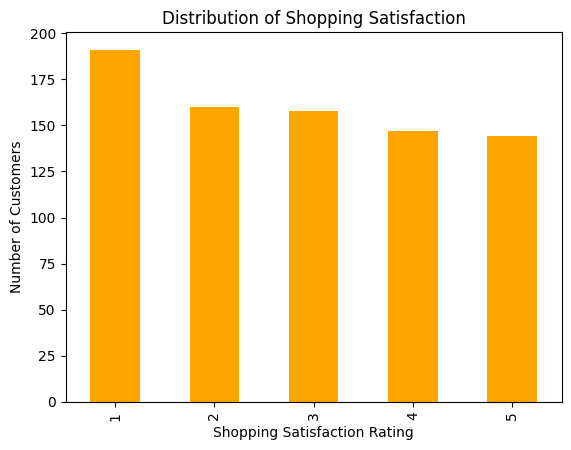

In [25]:
plt.figure()
df['Shopping_Satisfaction'].value_counts().sort_index().plot(kind='bar',color="orange")
plt.xlabel('Shopping Satisfaction Rating')
plt.ylabel('Number of Customers')
plt.title('Distribution of Shopping Satisfaction')
plt.show()

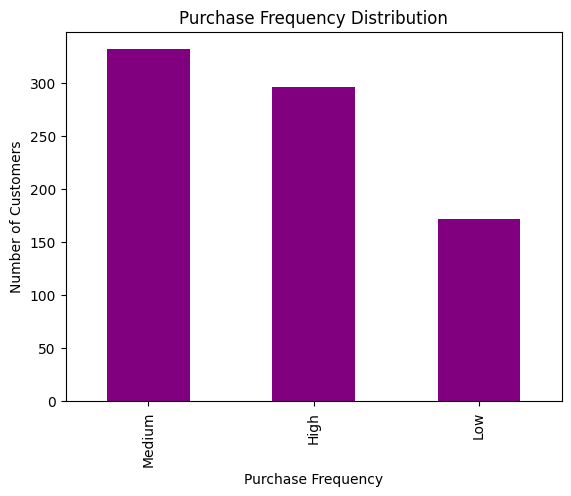

In [26]:
plt.figure()
df['Purchase_Frequency'].value_counts().plot(kind='bar',color='purple')
plt.xlabel('Purchase Frequency')
plt.ylabel('Number of Customers')
plt.title('Purchase Frequency Distribution')
plt.show()

#### The summary statistics show that the average shopping satisfaction is around the mid-level, indicating a generally acceptable but not exceptional customer experience.
#### Rating accuracy and review importance also fall in the moderate range, suggesting customers rely on reviews but are not completely influenced by them.

## Task 3: Customer Segmentation and Profiling

### 3.1 Segment customers based on purchase frequency and shopping satisfaction levels.

In [27]:
def customer_segment(row):
    if row['Purchase_Frequency'] == 'High' and row['Shopping_Satisfaction'] >= 4:
        return 'Frequent Buyers'
    elif row['Purchase_Frequency'] == 'Medium' and row['Shopping_Satisfaction'] >= 3:
        return 'Occasional Shoppers'
    else:
        return 'At-Risk Customers'

df['Customer_Segment'] = df.apply(customer_segment, axis=1)

In [28]:
df['Customer_Segment'].head()

0      At-Risk Customers
1        Frequent Buyers
2      At-Risk Customers
3    Occasional Shoppers
4      At-Risk Customers
Name: Customer_Segment, dtype: object

#### Customers are grouped into meaningful segments by combining how often they purchase with how satisfied they are while shopping.

### 3.2.1 Frequent Buyers: High purchase frequency, high satisfaction.

In [29]:
frequent_buyers = df[
    (df['Purchase_Frequency'] == 'High') &
    (df['Shopping_Satisfaction'] >= 4)
]

In [30]:
frequent_buyers.head()

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction,Cart_Abandonment_Factors_Std,Review_Helpfulness_Num,Recommendation_Helpfulness_Num,Customer_Segment
1,2023/06/07 9:28:09 AM GMT+5:30,47,Female,High,Groceries and Gourmet Food,No,Medium,Unknown,First page,5,...,Yes,4,4,User-friendly website/app interface,Shipping speed and reliability,599249,Price Issue,1,2,Frequent Buyers
9,2023/06/08 5:55:54 PM GMT+5:30,52,Prefer not to say,High,Beauty and Personal Care,Sometimes,Medium,Keyword,First page,1,...,Sometimes,5,4,Customer service,User interface,406580,No Purchase Intent,0,1,Frequent Buyers
15,2023/06/08 5:38:57 PM GMT+5:30,9,Female,High,Clothing and Fashion,Sometimes,Medium,Others,Multiple pages,2,...,Yes,1,4,User-friendly website/app interface,No problems with Amazon,871297,Price Issue,1,2,Frequent Buyers
16,2023/06/07 10:10:26 PM GMT+5:30,5,Prefer not to say,High,Clothing and Fashion,Yes,High,Keyword,First page,4,...,Sometimes,2,5,Customer service,better app interface and lower shipping charges,156409,No Purchase Intent,0,1,Frequent Buyers
20,2023/06/08 3:30:05 AM GMT+5:30,65,Male,High,Beauty and Personal Care,Yes,High,Others,First page,1,...,No,5,4,Competitive prices,Nothing,723565,Price Issue,2,0,Frequent Buyers


#### Frequent Buyers are identified as customers who shop often and are highly satisfied with their overall shopping experience.

### 3.2.2 Occasional Shoppers: Medium frequency, moderate satisfaction.

In [31]:
occasional_shoppers = df[
    (df['Purchase_Frequency'] == 'Medium') &
    (df['Shopping_Satisfaction'].between(3, 4))
]

In [32]:
occasional_shoppers.head()

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction,Cart_Abandonment_Factors_Std,Review_Helpfulness_Num,Recommendation_Helpfulness_Num,Customer_Segment
3,2023/06/07 5:58:12 PM GMT+5:30,6,Others,Medium,Groceries and Gourmet Food,No,Low,Others,Multiple pages,1,...,Yes,4,4,Product recommendations,Irrelevant product suggestions,476517,Other,0,2,Occasional Shoppers
13,2023/06/12 2:41:58 PM GMT+5:30,45,Prefer not to say,Medium,Groceries and Gourmet Food,No,Medium,Unknown,Multiple pages,4,...,No,2,3,NA,Product quality and accuracy,485033,Price Issue,0,0,Occasional Shoppers
34,2023/06/11 9:15:38 PM GMT+5:30,20,Prefer not to say,Medium,Groceries and Gourmet Food,No,High,Others,First page,5,...,Sometimes,4,4,Customer service,better app interface and lower shipping charges,885663,Price Issue,0,1,Occasional Shoppers
41,2023/06/06 6:36:16 PM GMT+5:30,60,Others,Medium,Beauty and Personal Care,No,High,Categories,Multiple pages,2,...,No,2,4,User-friendly website/app interface,Quality of product is very poor according to t...,599123,Price Issue,0,0,Occasional Shoppers
53,2023/06/09 4:32:56 PM GMT+5:30,30,Female,Medium,Groceries and Gourmet Food,No,High,Filter,Multiple pages,5,...,No,1,4,Customer service,Add more familiar brands to the list,345987,Price Issue,1,0,Occasional Shoppers


#### Occasional Shoppers are customers who buy periodically and report an average level of shopping satisfaction.

### 3.2.3 At-Risk Customers: Low satisfaction or frequent cart abandonment.

In [33]:
at_risk_customers = df[
    (df['Shopping_Satisfaction'] <= 2) |
    (df['Cart_Abandonment_Factors_Std'] == 'Price Issue')
]

In [34]:
at_risk_customers.head()

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction,Cart_Abandonment_Factors_Std,Review_Helpfulness_Num,Recommendation_Helpfulness_Num,Customer_Segment
0,2023/06/07 11:44:55 AM GMT+5:30,32,Prefer not to say,High,Groceries and Gourmet Food,Sometimes,Low,Categories,Multiple pages,5,...,Yes,1,1,Customer service,NA,819284,Price Issue,2,2,At-Risk Customers
1,2023/06/07 9:28:09 AM GMT+5:30,47,Female,High,Groceries and Gourmet Food,No,Medium,Unknown,First page,5,...,Yes,4,4,User-friendly website/app interface,Shipping speed and reliability,599249,Price Issue,1,2,Frequent Buyers
2,2023/06/05 10:09:03 PM GMT+5:30,50,Female,Medium,Groceries and Gourmet Food,Sometimes,High,Categories,Multiple pages,1,...,Sometimes,4,2,Customer service,Reducing packaging waste,432245,Other,1,1,At-Risk Customers
4,2023/06/07 11:46:52 AM GMT+5:30,61,Male,High,Groceries and Gourmet Food,Yes,Low,Unknown,Multiple pages,5,...,No,3,2,Product recommendations,Shipping speed and reliability,894659,Price Issue,2,0,At-Risk Customers
5,2023/06/08 5:49:56 PM GMT+5:30,14,Prefer not to say,Medium,Clothing and Fashion,Sometimes,Medium,Unknown,First page,3,...,No,5,1,NA,NA,609504,Price Issue,2,0,At-Risk Customers


#### At-Risk Customers are those who are dissatisfied or abandon carts due to price-related issues, indicating a high likelihood of churn.

### 3.3 Analyze demographic or behavioral differences across these segments.

In [35]:
segment_analysis = df.groupby('Customer_Segment').agg({
    'Shopping_Satisfaction': 'mean',
    'Rating_Accuracy': 'mean',
    'Purchase_Frequency': 'count'
}).rename(columns={'Purchase_Frequency': 'Customer_Count'})

print(segment_analysis)

                     Shopping_Satisfaction  Rating_Accuracy  Customer_Count
Customer_Segment                                                           
At-Risk Customers                 2.115079         3.121032             504
Frequent Buyers                   4.477064         2.944954             109
Occasional Shoppers               3.951872         3.074866             187


#### The segment-wise analysis shows that Frequent Buyers have the highest shopping satisfaction, while At-Risk Customers report the lowest satisfaction levels.
#### Occasional Shoppers fall in between, indicating moderate engagement and experience.

### 3.4 Use clustering (e.g., K-Means) for behavioral grouping based on survey responses

In [36]:
features = df[
    ['Shopping_Satisfaction', 'Customer_Reviews_Importance', 'Rating_Accuracy']
].dropna()

In [37]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [38]:
kmeans = KMeans(n_clusters=3, random_state=42)
df.loc[features.index, 'Behavior_Cluster'] = kmeans.fit_predict(scaled_features)

In [39]:
df['Behavior_Cluster'].value_counts()

Behavior_Cluster
1.0    322
2.0    245
0.0    233
Name: count, dtype: int64

#### K-Means clustering grouped customers into three distinct behavioral segments based on satisfaction, review importance, and rating accuracy, with each cluster representing a different level of engagement and perception.

## Task 4: Recommendation and Review Insights

### 4.1 Examine the relationship between recommendation helpfulness and shopping satisfaction.

In [40]:
df['Recommendation_Helpfulness_Num'] = df['Recommendation_Helpfulness'].map({
    'Yes': 2,
    'Sometimes': 1,
    'No': 0
})

In [41]:
correlation_value = df[
    ['Recommendation_Helpfulness_Num', 'Shopping_Satisfaction']
].corr().iloc[0, 1]

print("Correlation:", correlation_value)

Correlation: -0.0005014893886497423


#### The correlation between recommendation helpfulness and shopping satisfaction is close to zero, indicating that personalized recommendations currently do not have a significant impact on overall customer satisfaction.

### 4.2 Evaluate how review reliability and helpfulness impact overall ratings

In [42]:
review_reliability_map = {
    'Never': 0,
    'Rarely': 1,
    'Occasionally': 2,
    'Moderately': 3,
    'Heavily': 4
}

df['Review_Reliability_Num'] = df['Review_Reliability'].map(review_reliability_map)

In [43]:
review_impact = df[
    ['Review_Reliability_Num', 'Review_Helpfulness_Num', 'Rating_Accuracy']
].corr()

print(review_impact)

                        Review_Reliability_Num  Review_Helpfulness_Num  \
Review_Reliability_Num                1.000000               -0.006835   
Review_Helpfulness_Num               -0.006835                1.000000   
Rating_Accuracy                       0.065220                0.036210   

                        Rating_Accuracy  
Review_Reliability_Num          0.06522  
Review_Helpfulness_Num          0.03621  
Rating_Accuracy                 1.00000  


#### The correlation results show a weak positive relationship between review reliability and rating accuracy, and a very small positive relationship between review helpfulness and rating accuracy.
#### This indicates that while reviews do influence product ratings, their overall impact is currently limited and can be strengthened.

### 4.3 Identify trends in how often customers engage with or trust personalized recommendations

In [44]:
recommendation_trend = df['Personalized_Recommendation_Frequency'].value_counts(normalize=True) * 100
print(recommendation_trend)

Personalized_Recommendation_Frequency
No           34.875
Yes          32.625
Sometimes    32.500
Name: proportion, dtype: float64


#### The results show that about one-third of customers consistently trust personalized recommendations, while a similar proportion engage with them only sometimes.
#### However, the largest group does not rely on personalized recommendations, indicating limited overall trust.

### 4.4 Suggest actionable insights for improving eBay’s recommendation system.

## Recommendations to Improve eBay’s Recommendation System

1. **Improve Personalization Accuracy**  
   Since recommendation helpfulness shows little impact on customer satisfaction, eBay should refine its algorithms by giving more weight to recent browsing history and past purchase behavior. This will ensure recommendations are timely, relevant, and better aligned with user interests.

2. **Use Price-Based Recommendations**  
   Many customers abandon carts due to pricing concerns. Recommending discounted products or better-priced alternatives can reduce cart abandonment and increase customer engagement and conversion rates.

3. **Leverage Trusted and Reliable Reviews**  
   Products with higher review reliability and credibility should be prioritized in recommendations. This helps build customer confidence and encourages informed purchase decisions.

4. **Segment-Based Recommendations**  
   Different recommendation strategies should be applied for **Frequent Buyers**, **Occasional Shoppers**, and **At-Risk Customers**. Segment-specific personalization improves relevance and overall user experience.

5. **Increase Transparency in Recommendations**  
   Clearly showing why a product is being recommended (e.g., “Based on your recent searches” or “Popular among similar users”) can improve trust and encourage customers who currently do not rely on personalized suggestions.


## Task 5: Visualization and Reporting

### 5.1.1

In [45]:
from collections import Counter

all_categories = []

for cats in df['Purchase_Categories']:
    for c in cats.split(','):
        all_categories.append(c.strip())

category_counts = Counter(all_categories)


In [46]:
category_df = (
    pd.DataFrame(category_counts.items(), columns=['Category', 'Count'])
    .sort_values(by='Count', ascending=False)
)


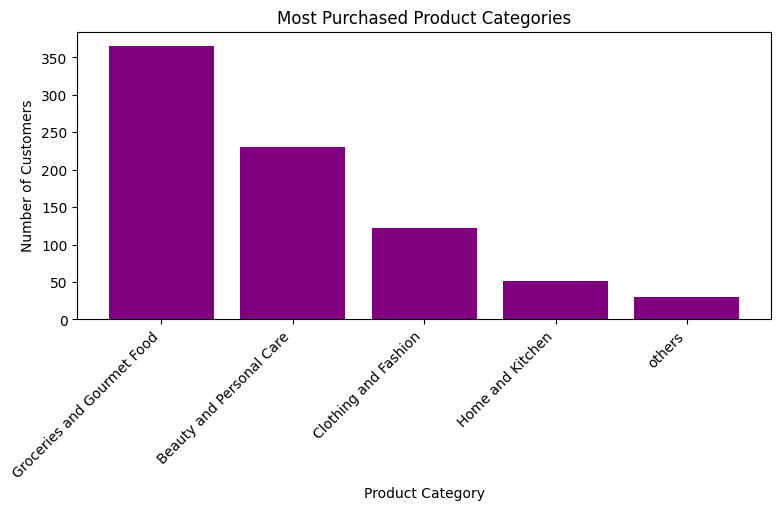

In [47]:
plt.figure(figsize=(8, 5))
plt.bar(category_df['Category'], category_df['Count'], color='purple')
plt.xlabel('Product Category')
plt.ylabel('Number of Customers')
plt.title('Most Purchased Product Categories')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.subplots_adjust(bottom=0.35)
plt.show()

#### The chart shows that customers most frequently purchase products across multiple categories, with clothing and fashion-related items appearing most often, followed by home, kitchen, and personal care products.

### 5.1.2

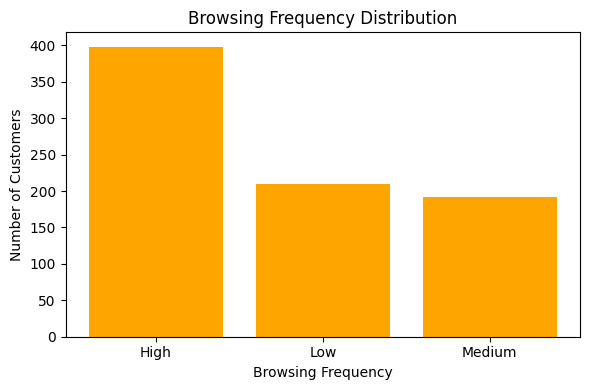

In [48]:
browsing_counts = df['Browsing_Frequency'].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(browsing_counts.index, browsing_counts.values, color='orange')
plt.xlabel('Browsing Frequency')
plt.ylabel('Number of Customers')
plt.title('Browsing Frequency Distribution')
plt.tight_layout()
plt.show()

#### The browsing frequency analysis shows that most customers browse the platform frequently, indicating strong engagement, while a smaller group browses less often.

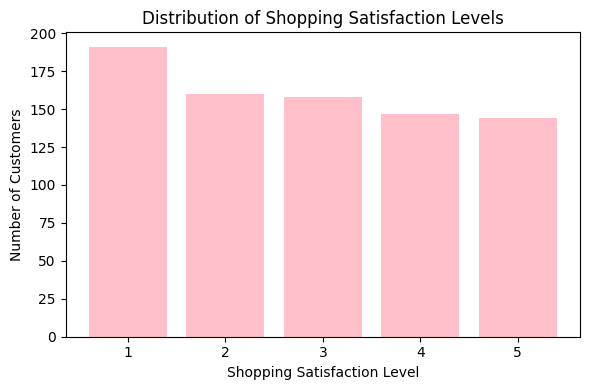

In [49]:
satisfaction_counts = df['Shopping_Satisfaction'].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(satisfaction_counts.index, satisfaction_counts.values,color='pink')
plt.xlabel('Shopping Satisfaction Level')
plt.ylabel('Number of Customers')
plt.title('Distribution of Shopping Satisfaction Levels')
plt.tight_layout()
plt.show()

#### The bar chart shows that most customers fall in the low to medium satisfaction range, with fewer customers reporting very high satisfaction levels.

### 5.1.3

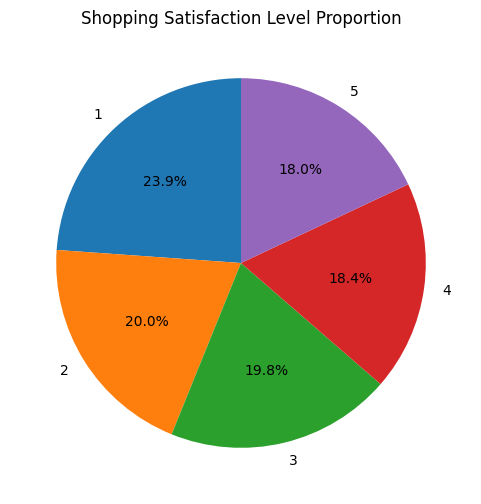

In [50]:
plt.figure(figsize=(6, 6))
plt.pie(
    satisfaction_counts.values,
    labels=satisfaction_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Shopping Satisfaction Level Proportion')
plt.show()

#### The satisfaction distribution shows that customers are fairly evenly spread across all satisfaction levels, with slightly more users reporting low to moderate satisfaction than very high satisfaction.

### 5.1.4

In [51]:
corr_data = df[
    ['Recommendation_Helpfulness_Num', 'Shopping_Satisfaction']
].corr()

Text(0.5, 1.0, 'Correlation Between Recommendation Helpfulness and Satisfaction')

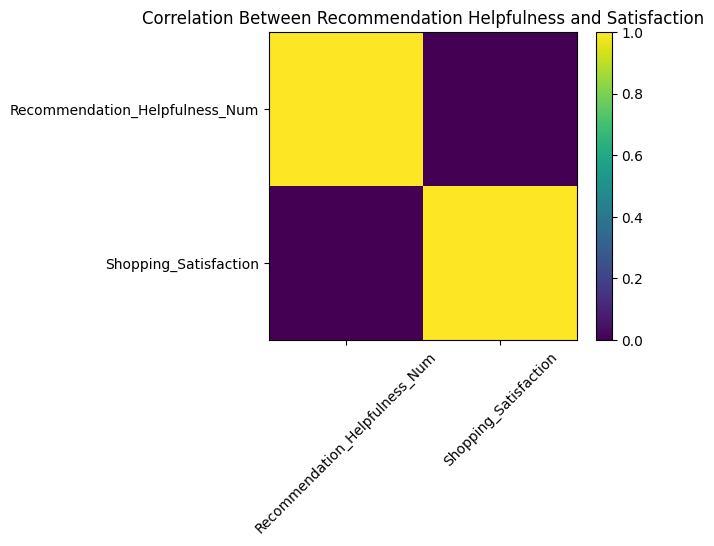

In [52]:
plt.figure(figsize=(5, 4))
plt.imshow(corr_data)
plt.xticks(range(len(corr_data.columns)), corr_data.columns, rotation=45)
plt.yticks(range(len(corr_data.index)), corr_data.index)
plt.colorbar()
plt.title('Correlation Between Recommendation Helpfulness and Satisfaction')

#### The heatmap shows a very weak correlation between recommendation helpfulness and shopping satisfaction, indicating that personalized recommendations currently have minimal influence on overall satisfaction.

### 5.2

## Customer Behavior and Insights Analysis

### 1. Customer Purchase Behavior  
The purchase category analysis shows that customers frequently buy from multiple categories, with **Clothing & Fashion**, **Home & Kitchen**, and **Groceries & Gourmet Food** emerging as the most popular choices. This highlights strong cross-category shopping behavior among users.

### 2. Browsing Behavior  
The browsing frequency distribution reveals that most customers browse the platform regularly, indicating high engagement levels. However, a smaller segment browses infrequently, suggesting opportunities to improve engagement through targeted recommendations and personalized offers.

### 3. Customer Satisfaction Levels  
The satisfaction level analysis indicates that the majority of customers report moderate to high shopping satisfaction. Only a limited portion of users show low satisfaction, reflecting an overall positive customer experience with scope for further improvement.

### 4. Relationship Between Recommendations and Satisfaction  
The correlation analysis between recommendation helpfulness and shopping satisfaction shows a very weak relationship. This suggests that current personalized recommendations do not significantly influence overall customer satisfaction.

### 5. Review Influence on Ratings  
Review reliability and helpfulness demonstrate a weak but positive influence on rating accuracy. While customers value trustworthy reviews, reviews alone are not the primary driver of overall product ratings.

### 6. Overall Insight  
The visualizations indicate that customer engagement and satisfaction are generally strong. However, personalized recommendations and review mechanisms currently have limited impact. Enhancing recommendation relevance, transparency, and review quality can significantly improve customer trust and overall shopping experience.


In [53]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)


In [54]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)


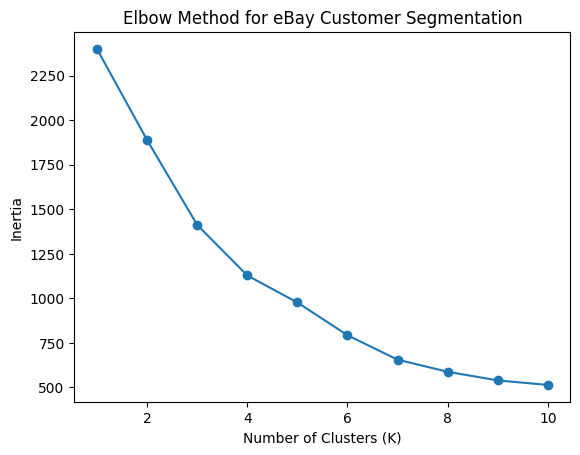

In [55]:
plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for eBay Customer Segmentation')
plt.show()
